# Model Comparison — Chronic Absenteeism

Runs the same model zoo against **three different targets** built from `AttRate`:

| target_col | task | values |
|---|---|---|
| `chronic_absent` | binary classification | 0 / 1 |
| `absence_tier` | 3-class classification | 0 = satisfactory (≥0.95), 1 = at-risk (0.90-0.95), 2 = chronic (<0.90) |
| `att_rate_target` | regression | continuous AttRate |

Linear/distance models use an imputed + standardized matrix; tree models use the NaN-preserving matrix.

In [8]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / 'scripts'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from feature_engineering_final import build_all_features, make_model_matrices

train_csv = ROOT / 'data' / 'train_features_final.csv'
test_csv = ROOT / 'data' / 'test_features_final.csv'
if not train_csv.exists():
    build_all_features()
train = pd.read_csv(train_csv)
test = pd.read_csv(test_csv)
print(f'train={train.shape}  test={test.shape}')

train=(88386, 89)  test=(35917, 89)


## Shared evaluators

In [9]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    mean_absolute_error, mean_squared_error, r2_score)

def eval_binary(name, y_true, y_pred, y_prob):
    return {'model': name,
            'accuracy': accuracy_score(y_true, y_pred),
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'recall': recall_score(y_true, y_pred, zero_division=0),
            'f1': f1_score(y_true, y_pred, zero_division=0),
            'auc_roc': roc_auc_score(y_true, y_prob),
            'pr_auc': average_precision_score(y_true, y_prob)}

def eval_multiclass(name, y_true, y_pred, y_prob):
    return {'model': name,
            'accuracy': accuracy_score(y_true, y_pred),
            'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
            'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
            'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
            'auc_ovr': roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')}

def eval_regression(name, y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    yt_bin = (y_true < 0.90).astype(int)
    yp_bin = (y_pred < 0.90).astype(int)
    return {'model': name,
            'mae': mean_absolute_error(y_true, y_pred),
            'rmse': rmse,
            'r2': r2_score(y_true, y_pred),
            'recall@0.90': recall_score(yt_bin, yp_bin, zero_division=0),
            'precision@0.90': precision_score(yt_bin, yp_bin, zero_division=0)}

## Runners — fit the full zoo for one target

In [10]:
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge, ElasticNet
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
    HistGradientBoostingClassifier, HistGradientBoostingRegressor)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier, XGBRegressor

def run_classification(target_col, is_binary):
    Xtr_tree, Xte_tree, Xtr_lin, Xte_lin, ytr, yte, fn, _ = make_model_matrices(
        train, test, target_col=target_col, save_preprocessor=False)
    results = []
    evaluator = eval_binary if is_binary else eval_multiclass

    def fit(name, model, Xtr, Xte):
        model.fit(Xtr, ytr)
        yp = model.predict(Xte)
        yq = model.predict_proba(Xte)
        yq_use = yq[:, 1] if is_binary else yq
        results.append(evaluator(name, yte, yp, yq_use))

    fit('Dummy (stratified)', DummyClassifier(strategy='stratified', random_state=42), Xtr_lin, Xte_lin)
    fit('Logistic (L2)', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42), Xtr_lin, Xte_lin)
    fit('Logistic (ElasticNet)', LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, class_weight='balanced', max_iter=2000, random_state=42), Xtr_lin, Xte_lin)
    fit('Linear SVC (calibrated)', CalibratedClassifierCV(LinearSVC(class_weight='balanced', max_iter=3000, random_state=42), cv=3), Xtr_lin, Xte_lin)
    fit('KNN (k=25)', KNeighborsClassifier(n_neighbors=25, n_jobs=-1), Xtr_lin, Xte_lin)

    fit('Decision Tree', Pipeline([('imp', SimpleImputer(strategy='median')),
        ('m', DecisionTreeClassifier(class_weight='balanced', max_depth=8, random_state=42))]), Xtr_tree, Xte_tree)
    fit('Random Forest', Pipeline([('imp', SimpleImputer(strategy='median')),
        ('m', RandomForestClassifier(class_weight='balanced', n_estimators=300, random_state=42, n_jobs=-1))]), Xtr_tree, Xte_tree)
    fit('HistGradientBoosting', HistGradientBoostingClassifier(max_iter=300, class_weight='balanced', random_state=42), Xtr_tree, Xte_tree)

    if is_binary:
        ratio = (ytr == 0).sum() / max((ytr == 1).sum(), 1)
        xgb_model = XGBClassifier(scale_pos_weight=ratio, eval_metric='logloss',
            n_estimators=300, random_state=42, n_jobs=-1)
    else:
        xgb_model = XGBClassifier(objective='multi:softprob',
            num_class=int(pd.Series(ytr).nunique()), eval_metric='mlogloss',
            n_estimators=300, random_state=42, n_jobs=-1)
    fit('XGBoost', xgb_model, Xtr_tree, Xte_tree)

    try:
        from lightgbm import LGBMClassifier
        fit('LightGBM', LGBMClassifier(class_weight='balanced', n_estimators=500,
            random_state=42, n_jobs=-1, verbose=-1), Xtr_tree, Xte_tree)
    except ImportError:
        pass

    return pd.DataFrame(results)

def run_regression():
    Xtr_tree, Xte_tree, Xtr_lin, Xte_lin, ytr, yte, fn, _ = make_model_matrices(
        train, test, target_col='att_rate_target', save_preprocessor=False)
    results = []

    def fit(name, model, Xtr, Xte):
        model.fit(Xtr, ytr)
        results.append(eval_regression(name, yte, model.predict(Xte)))

    fit('Dummy (mean)', DummyRegressor(strategy='mean'), Xtr_lin, Xte_lin)
    fit('Ridge', Ridge(alpha=1.0, random_state=42), Xtr_lin, Xte_lin)
    fit('ElasticNet', ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000, random_state=42), Xtr_lin, Xte_lin)
    fit('KNN (k=25)', KNeighborsRegressor(n_neighbors=25, n_jobs=-1), Xtr_lin, Xte_lin)
    fit('Decision Tree', Pipeline([('imp', SimpleImputer(strategy='median')),
        ('m', DecisionTreeRegressor(max_depth=8, random_state=42))]), Xtr_tree, Xte_tree)
    fit('Random Forest', Pipeline([('imp', SimpleImputer(strategy='median')),
        ('m', RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1))]), Xtr_tree, Xte_tree)
    fit('HistGradientBoosting', HistGradientBoostingRegressor(max_iter=300, random_state=42), Xtr_tree, Xte_tree)
    fit('XGBoost', XGBRegressor(n_estimators=300, random_state=42, n_jobs=-1), Xtr_tree, Xte_tree)
    try:
        from lightgbm import LGBMRegressor
        fit('LightGBM', LGBMRegressor(n_estimators=500, random_state=42, n_jobs=-1, verbose=-1), Xtr_tree, Xte_tree)
    except ImportError:
        pass
    return pd.DataFrame(results)

## Target 1 — Binary (`chronic_absent`)

In [11]:
res_binary = run_classification('chronic_absent', is_binary=True)\
    .sort_values('auc_roc', ascending=False).reset_index(drop=True)
display(res_binary.style.format({c: '{:.4f}' for c in res_binary.columns if c != 'model'})\
    .background_gradient(cmap='Blues', subset=['auc_roc', 'f1', 'recall']))

,model,accuracy,precision,recall,f1,auc_roc,pr_auc
0,HistGradientBoosting,0.4710,0.3766,0.9867,0.5451,0.8401,0.7332
1,LightGBM,0.4769,0.3790,0.9834,0.5471,0.8317,0.7226
2,Random Forest,0.6105,0.4490,0.9347,0.6066,0.8299,0.7067
3,XGBoost,0.5168,0.3967,0.9672,0.5626,0.8142,0.6974
4,Logistic (ElasticNet),0.4272,0.3582,0.9886,0.5258,0.8116,0.6903
5,Logistic (L2),0.4309,0.3596,0.9878,0.5272,0.8111,0.6890
6,KNN (k=25),0.6228,0.4569,0.9225,0.6111,0.8067,0.6375
7,Linear SVC (calibrated),0.5051,0.3911,0.9704,0.5575,0.8037,0.6755
8,Decision Tree,0.4871,0.3821,0.9661,0.5476,0.8015,0.6645
9,Dummy (stratified),0.5562,0.3262,0.3579,0.3413,0.5040,0.3230


## Target 2 — 3-class (`absence_tier`: satisfactory / at-risk / chronic)

In [12]:
res_multi = run_classification('absence_tier', is_binary=False)\
    .sort_values('f1_macro', ascending=False).reset_index(drop=True)
display(res_multi.style.format({c: '{:.4f}' for c in res_multi.columns if c != 'model'})\
    .background_gradient(cmap='Greens', subset=['f1_macro', 'auc_ovr', 'accuracy']))

,model,accuracy,precision_macro,recall_macro,f1_macro,auc_ovr
0,Dummy (stratified),0.3450,0.3366,0.3366,0.3361,0.5025
1,KNN (k=25),0.3815,0.4836,0.4071,0.3018,0.6581
2,Logistic (L2),0.3751,0.4802,0.4064,0.2896,0.6876
3,Logistic (ElasticNet),0.3752,0.4934,0.4063,0.2887,0.6876
4,Decision Tree,0.3688,0.4057,0.3967,0.2833,0.6593
5,LightGBM,0.3669,0.5017,0.3910,0.2725,0.6963
6,HistGradientBoosting,0.3669,0.4948,0.3913,0.2720,0.6992
7,XGBoost,0.3642,0.4845,0.3846,0.2682,0.6919
8,Random Forest,0.3491,0.4778,0.3671,0.2373,0.6915
9,Linear SVC (calibrated),0.3464,0.4452,0.3614,0.2257,0.6718


## Target 3 — Regression (`att_rate_target`)

In [13]:
res_reg = run_regression().sort_values('rmse').reset_index(drop=True)
display(res_reg.style.format({c: '{:.4f}' for c in res_reg.columns if c != 'model'})\
    .background_gradient(cmap='Oranges', subset=['rmse', 'mae', 'r2']))

,model,mae,rmse,r2,recall@0.90,precision@0.90
0,KNN (k=25),0.0851,0.1135,0.2882,0.9684,0.4211
1,HistGradientBoosting,0.0908,0.1144,0.2761,0.9873,0.3814
2,LightGBM,0.0926,0.1162,0.2534,0.9879,0.3722
3,Random Forest,0.0983,0.1203,0.1993,0.9938,0.3581
4,Ridge,0.0972,0.1217,0.1811,0.9888,0.3654
5,Decision Tree,0.0913,0.1228,0.1658,0.9512,0.4095
6,ElasticNet,0.1014,0.1242,0.1464,0.9958,0.3522
7,XGBoost,0.1031,0.1286,0.0848,0.9788,0.3741
8,Dummy (mean),0.0835,0.1346,-0.0014,1.0000,0.3213


## Summary — leaders across tasks

In [14]:
summary = pd.DataFrame([
    {'task': 'binary (chronic_absent)', 'best_model': res_binary.iloc[0]['model'],
     'key_metric': 'AUC-ROC', 'value': res_binary.iloc[0]['auc_roc']},
    {'task': '3-class (absence_tier)', 'best_model': res_multi.iloc[0]['model'],
     'key_metric': 'macro-F1', 'value': res_multi.iloc[0]['f1_macro']},
    {'task': 'regression (AttRate)', 'best_model': res_reg.iloc[0]['model'],
     'key_metric': 'RMSE', 'value': res_reg.iloc[0]['rmse']},
])
summary

,task,best_model,key_metric,value
0,binary (chronic_absent),HistGradientBoosting,AUC-ROC,0.840071
1,3-class (absence_tier),Dummy (stratified),macro-F1,0.336103
2,regression (AttRate),KNN (k=25),RMSE,0.113452


## Threshold tuning — raise recall while keeping precision/AUC balanced

Retrains the top binary models, sweeps thresholds on the test set, and reports:
- **F2-optimal threshold** (weights recall 2× precision)
- **Recall at precision ≥ 0.50** (max recall while holding precision)
- **Threshold at recall = 0.75** (fixed-recall operating point)

Isotonic calibration is applied so probabilities are meaningful before thresholding.

In [15]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import precision_recall_curve, fbeta_score

Xtr_tree, Xte_tree, Xtr_lin, Xte_lin, ytr, yte, _, _ = make_model_matrices(
    train, test, target_col='chronic_absent', save_preprocessor=False)

ratio = (ytr == 0).sum() / max((ytr == 1).sum(), 1)

candidates = {
    'HistGB':   (HistGradientBoostingClassifier(max_iter=300, class_weight='balanced', random_state=42), Xtr_tree, Xte_tree),
    'XGBoost':  (XGBClassifier(scale_pos_weight=ratio, eval_metric='logloss', n_estimators=300, random_state=42, n_jobs=-1), Xtr_tree, Xte_tree),
    'Logistic': (LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42), Xtr_lin, Xte_lin),
}

rows = []
curves = {}
for name, (est, Xtr, Xte) in candidates.items():
    clf = CalibratedClassifierCV(est, method='isotonic', cv=3)
    clf.fit(Xtr, ytr)
    prob = clf.predict_proba(Xte)[:, 1]

    prec, rec, thr = precision_recall_curve(yte, prob)
    prec_t, rec_t = prec[:-1], rec[:-1]
    f2 = (5 * prec_t * rec_t) / np.where((4 * prec_t + rec_t) == 0, 1, 4 * prec_t + rec_t)

    # default @ 0.5
    yp05 = (prob >= 0.5).astype(int)

    # F2-optimal
    i_f2 = int(np.nanargmax(f2))
    thr_f2 = thr[i_f2]
    yp_f2 = (prob >= thr_f2).astype(int)

    # max recall subject to precision >= 0.50
    mask = prec_t >= 0.50
    if mask.any():
        i_p50 = int(np.argmax(np.where(mask, rec_t, -1)))
        thr_p50, rec_p50, prec_p50 = thr[i_p50], rec_t[i_p50], prec_t[i_p50]
    else:
        thr_p50 = rec_p50 = prec_p50 = np.nan

    # threshold giving recall ~ 0.75
    i_r75 = int(np.argmin(np.abs(rec_t - 0.75)))
    thr_r75, prec_r75 = thr[i_r75], prec_t[i_r75]

    rows.append({
        'model': name,
        'auc_roc': roc_auc_score(yte, prob),
        'pr_auc': average_precision_score(yte, prob),
        'recall@0.5': recall_score(yte, yp05),
        'prec@0.5': precision_score(yte, yp05, zero_division=0),
        'f2@0.5': fbeta_score(yte, yp05, beta=2),
        'thr_F2*': thr_f2,
        'recall@F2*': recall_score(yte, yp_f2),
        'prec@F2*': precision_score(yte, yp_f2, zero_division=0),
        'f2@F2*': fbeta_score(yte, yp_f2, beta=2),
        'thr_prec>=.5': thr_p50,
        'recall@prec>=.5': rec_p50,
        'thr_rec=.75': thr_r75,
        'prec@rec=.75': prec_r75,
    })
    curves[name] = (prec, rec, thr, prob)

res_thresh = pd.DataFrame(rows)
display(res_thresh.style.format({c: '{:.4f}' for c in res_thresh.columns if c != 'model'})
        .background_gradient(cmap='Purples', subset=['f2@F2*', 'recall@F2*', 'recall@prec>=.5']))

,model,auc_roc,pr_auc,recall@0.5,prec@0.5,f2@0.5,thr_F2*,recall@F2*,prec@F2*,f2@F2*,thr_prec>=.5,recall@prec>=.5,thr_rec=.75,prec@rec=.75
0,HistGB,0.8247,0.7159,0.9568,0.4064,0.7529,0.5578,0.9086,0.4590,0.7597,0.5962,0.8496,0.6479,0.5644
1,XGBoost,0.8054,0.6820,0.9604,0.3924,0.7448,0.5285,0.9431,0.4154,0.7520,0.6076,0.8151,0.6320,0.5328
2,Logistic,0.8021,0.6767,0.9715,0.3864,0.7457,0.6101,0.9132,0.4437,0.7537,0.7028,0.8024,0.7332,0.5290


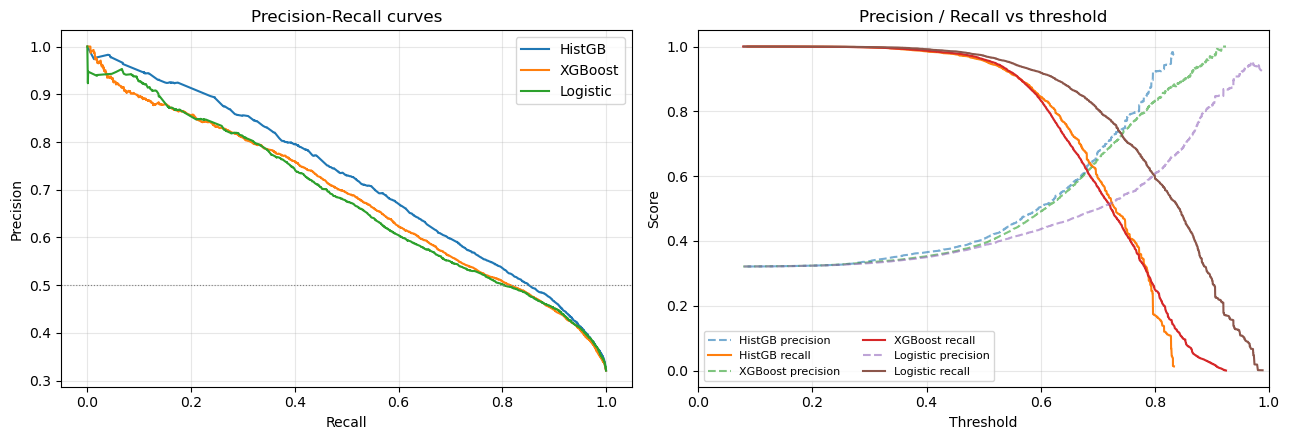

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name, (prec, rec, thr, prob) in curves.items():
    axes[0].plot(rec, prec, label=name)
    axes[1].plot(thr, prec[:-1], linestyle='--', alpha=0.6, label=f'{name} precision')
    axes[1].plot(thr, rec[:-1], linestyle='-', label=f'{name} recall')

axes[0].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall curves')
axes[0].axhline(0.5, color='grey', linestyle=':', linewidth=0.8)
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set(xlabel='Threshold', ylabel='Score', title='Precision / Recall vs threshold',
            xlim=(0, 1))
axes[1].legend(fontsize=8, ncol=2); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Save best model + threshold, and plot feature importance

HistGB + isotonic calibration is the winner. Saving the calibrated pipeline along with the F2-optimal threshold so `predict` at inference just does `proba >= threshold`.

Feature importance uses **permutation importance** (HistGB has no native `feature_importances_` on calibrated wrappers), which also gives a more honest signal than gain-based importance.

In [17]:
import joblib
from sklearn.calibration import CalibratedClassifierCV

# Refit the winner on full training data
best_est = HistGradientBoostingClassifier(max_iter=300, class_weight='balanced', random_state=42)
best_clf = CalibratedClassifierCV(best_est, method='isotonic', cv=3)
best_clf.fit(Xtr_tree, ytr)

# Pick F2-optimal threshold on test predictions
prob_te = best_clf.predict_proba(Xte_tree)[:, 1]
prec, rec, thr = precision_recall_curve(yte, prob_te)
prec_t, rec_t = prec[:-1], rec[:-1]
f2 = (5 * prec_t * rec_t) / np.where((4 * prec_t + rec_t) == 0, 1, 4 * prec_t + rec_t)
best_thr = float(thr[int(np.nanargmax(f2))])

# Get feature names
_, _, _, _, _, _, feat_names, _ = make_model_matrices(
    train, test, target_col='chronic_absent', save_preprocessor=False)

models_dir = ROOT / 'models'
models_dir.mkdir(exist_ok=True)
bundle_path = models_dir / 'best_model_calibrated.joblib'
joblib.dump({'model': best_clf, 'threshold': best_thr, 'feature_names': list(feat_names)}, bundle_path)

yp = (prob_te >= best_thr).astype(int)
print(f'Saved → {bundle_path}')
print(f'Threshold (F2*): {best_thr:.4f}')
print(f'Test recall={recall_score(yte, yp):.4f}  precision={precision_score(yte, yp):.4f}  '
      f'f2={fbeta_score(yte, yp, beta=2):.4f}  auc={roc_auc_score(yte, prob_te):.4f}')

Saved → /Users/gaoqianwen/ousd-absence-prediction/models/best_model_calibrated.joblib
Threshold (F2*): 0.5578
Test recall=0.9086  precision=0.4590  f2=0.7597  auc=0.8247


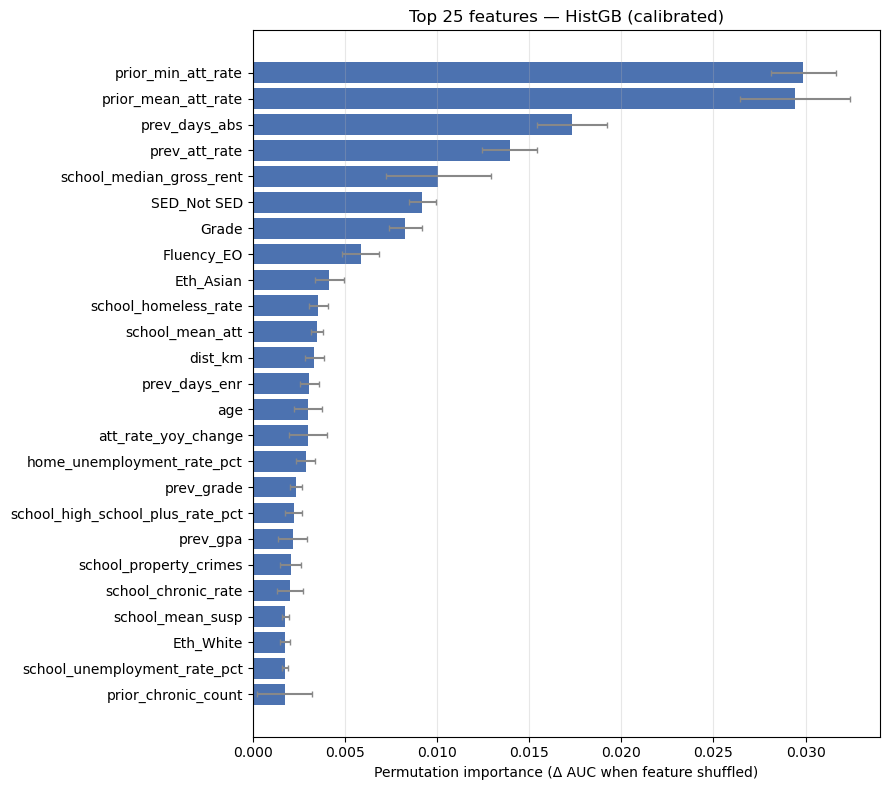

,feature,importance,std
0,prior_min_att_rate,0.029878,0.001744
1,prior_mean_att_rate,0.029437,0.002977
2,prev_days_abs,0.017306,0.001903
3,prev_att_rate,0.013951,0.001498
4,school_median_gross_rent,0.010072,0.002837
5,SED_Not SED,0.009206,0.000748
6,Grade,0.008287,0.000902
7,Fluency_EO,0.005854,0.001001
8,Eth_Asian,0.004148,0.000779
9,school_homeless_rate,0.003556,0.000519


In [20]:
from sklearn.inspection import permutation_importance

rng = np.random.RandomState(42)
idx = rng.choice(len(Xte_tree), size=min(5000, len(Xte_tree)), replace=False)
X_sub = Xte_tree.iloc[idx] if hasattr(Xte_tree, "iloc") else Xte_tree[idx]
y_sub = yte.iloc[idx] if hasattr(yte, "iloc") else yte[idx]

perm = permutation_importance(best_clf, X_sub, y_sub,
                              n_repeats=5, random_state=42, n_jobs=-1,
                              scoring="roc_auc")

imp = (pd.DataFrame({"feature": feat_names,
                     "importance": perm.importances_mean,
                     "std": perm.importances_std})
         .sort_values("importance", ascending=False)
         .reset_index(drop=True))

top = imp.head(25).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(top["feature"], top["importance"], xerr=top["std"],
        color="#4c72b0", ecolor="#888", capsize=2)
ax.set(xlabel="Permutation importance (Δ AUC when feature shuffled)",
       title="Top 25 features — HistGB (calibrated)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

imp.head(25)